In [4]:
import sys
sys.path.insert(0, '../')

from src.load_data import PatientLoader
from src.process import NeuroFeatureExtractor

## Import Data

In [5]:
from nilearn import plotting, image, masking

In [6]:
file_path = "data/sub-1004"
loader = PatientLoader()
recording = loader.load(file_path)

## Connectivity analysis

https://nilearn.github.io/dev/auto_examples/04_glm_first_level/plot_adhd_dmn.html
https://medium.com/data-science/using-neural-networks-for-a-functional-connectivity-classification-of-fmri-data-ff0999057bc6

https://medium.com/data-science/using-neural-networks-for-a-functional-connectivity-classification-of-fmri-data-ff0999057bc6

In [ ]:
import numpy as np

from nilearn import plotting
from nilearn.glm.first_level import (
    FirstLevelModel,
    make_first_level_design_matrix,
)
from nilearn.maskers import NiftiSpheresMasker

### Extract the seed region's time course

In [ ]:
# Para preparar la sed
plotting.view_img(recording.anat.img, bg_img=None)

In [ ]:
# Prepare seed
pcc_coords = (5, 7, -2)

In [ ]:
seed_masker = NiftiSpheresMasker(
    [pcc_coords],
    radius=10,
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=recording.func.sampling_period, #sampling period of the data
    memory="nilearn_cache",
    mask_img=None,
    memory_level=1,
    verbose=1,
)

seed_time_series = seed_masker.fit_transform(recording.func.img)

n_scans = seed_time_series.shape[0]
frametimes = np.linspace(0, (n_scans - 1) * recording.func.sampling_period, n_scans)

### Estimate contrasts

In [ ]:
design_matrix = make_first_level_design_matrix(
    frametimes,
    hrf_model="spm",
    add_regs=seed_time_series,
    add_reg_names=["pcc_seed"],
)
dmn_contrast = np.array([1] + [0] * (design_matrix.shape[1] - 1))
contrasts = {"seed_based_glm": dmn_contrast}

### Perform first level analysis

In [ ]:
first_level_model = FirstLevelModel(verbose=1)
first_level_model = first_level_model.fit(
    run_imgs=recording.func.img, design_matrices=design_matrix)

In [ ]:
print("Contrast seed_based_glm computed.")
z_map = first_level_model.compute_contrast(
    contrasts["seed_based_glm"], output_type="z_score"
)

In [ ]:
display = plotting.plot_stat_map(
    z_map, bg_img=recording.anat.img, threshold=3.0, title="Seed based GLM", cut_coords=pcc_coords
)
display.add_markers(
    marker_coords=[pcc_coords], marker_color="g", marker_size=300
)

In [ ]:
report = first_level_model.generate_report(
    contrasts=contrasts,
    title="Patient 1004 DMN Report",
    cluster_threshold=15,
    min_distance=8.0,
    bg_img=recording.anat.img # Forzamos al reporte a usar el fondo del paciente
)

In [ ]:
report

## Correlation Matrix --> a partir de atlas

[fetch_atlas_harvard_oxford] Dataset found in C:\Users\ainho\nilearn_data\fsl
[NiftiLabelsMasker.wrapped] loading data from Nifti1Image(
shape=(91, 109, 91),
affine=array([[   2.,    0.,    0.,  -90.],
       [   0.,    2.,    0., -126.],
       [   0.,    0.,    2.,  -72.],
       [   0.,    0.,    0.,    1.]])
)
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker.filter_and_extract...
filter_and_extract(<nibabel.nifti1.Nifti1Image object at 0x000001BA1B64AD60>, <nilearn.maskers.nifti_labels_masker._ExtractionFunctor object at 0x000001BA1B67BF10>, 
{ 'background_label': 0,
  'clean_args': None,
  'clean_kwargs': {},
  'cmap': 'CMRmap_r',
  'detrend': True,
  'dtype': None,
  'high_pass': 0.01,
  'high_variance_confounds': False,
  'keep_masked_labels': True,
  'labels': None,
  'labels_img': <nibabel.nifti1.Nifti1Image object at 0x000001BA1AB081C0>,
  'low_pass': 0.1,
  'lut': None,
  'mask_img': None,
  'report

D:\Programas\anaconda\envs\neuroimage\lib\site-packages\joblib\memory.py:326: UserWarning: Casting data from int16 to float32
  return self.func(*args, **kwargs)


[NiftiLabelsMasker.wrapped] Extracting region signals
[NiftiLabelsMasker.wrapped] Cleaning extracted signals
______________________________________________filter_and_extract - 65.2s, 1.1min


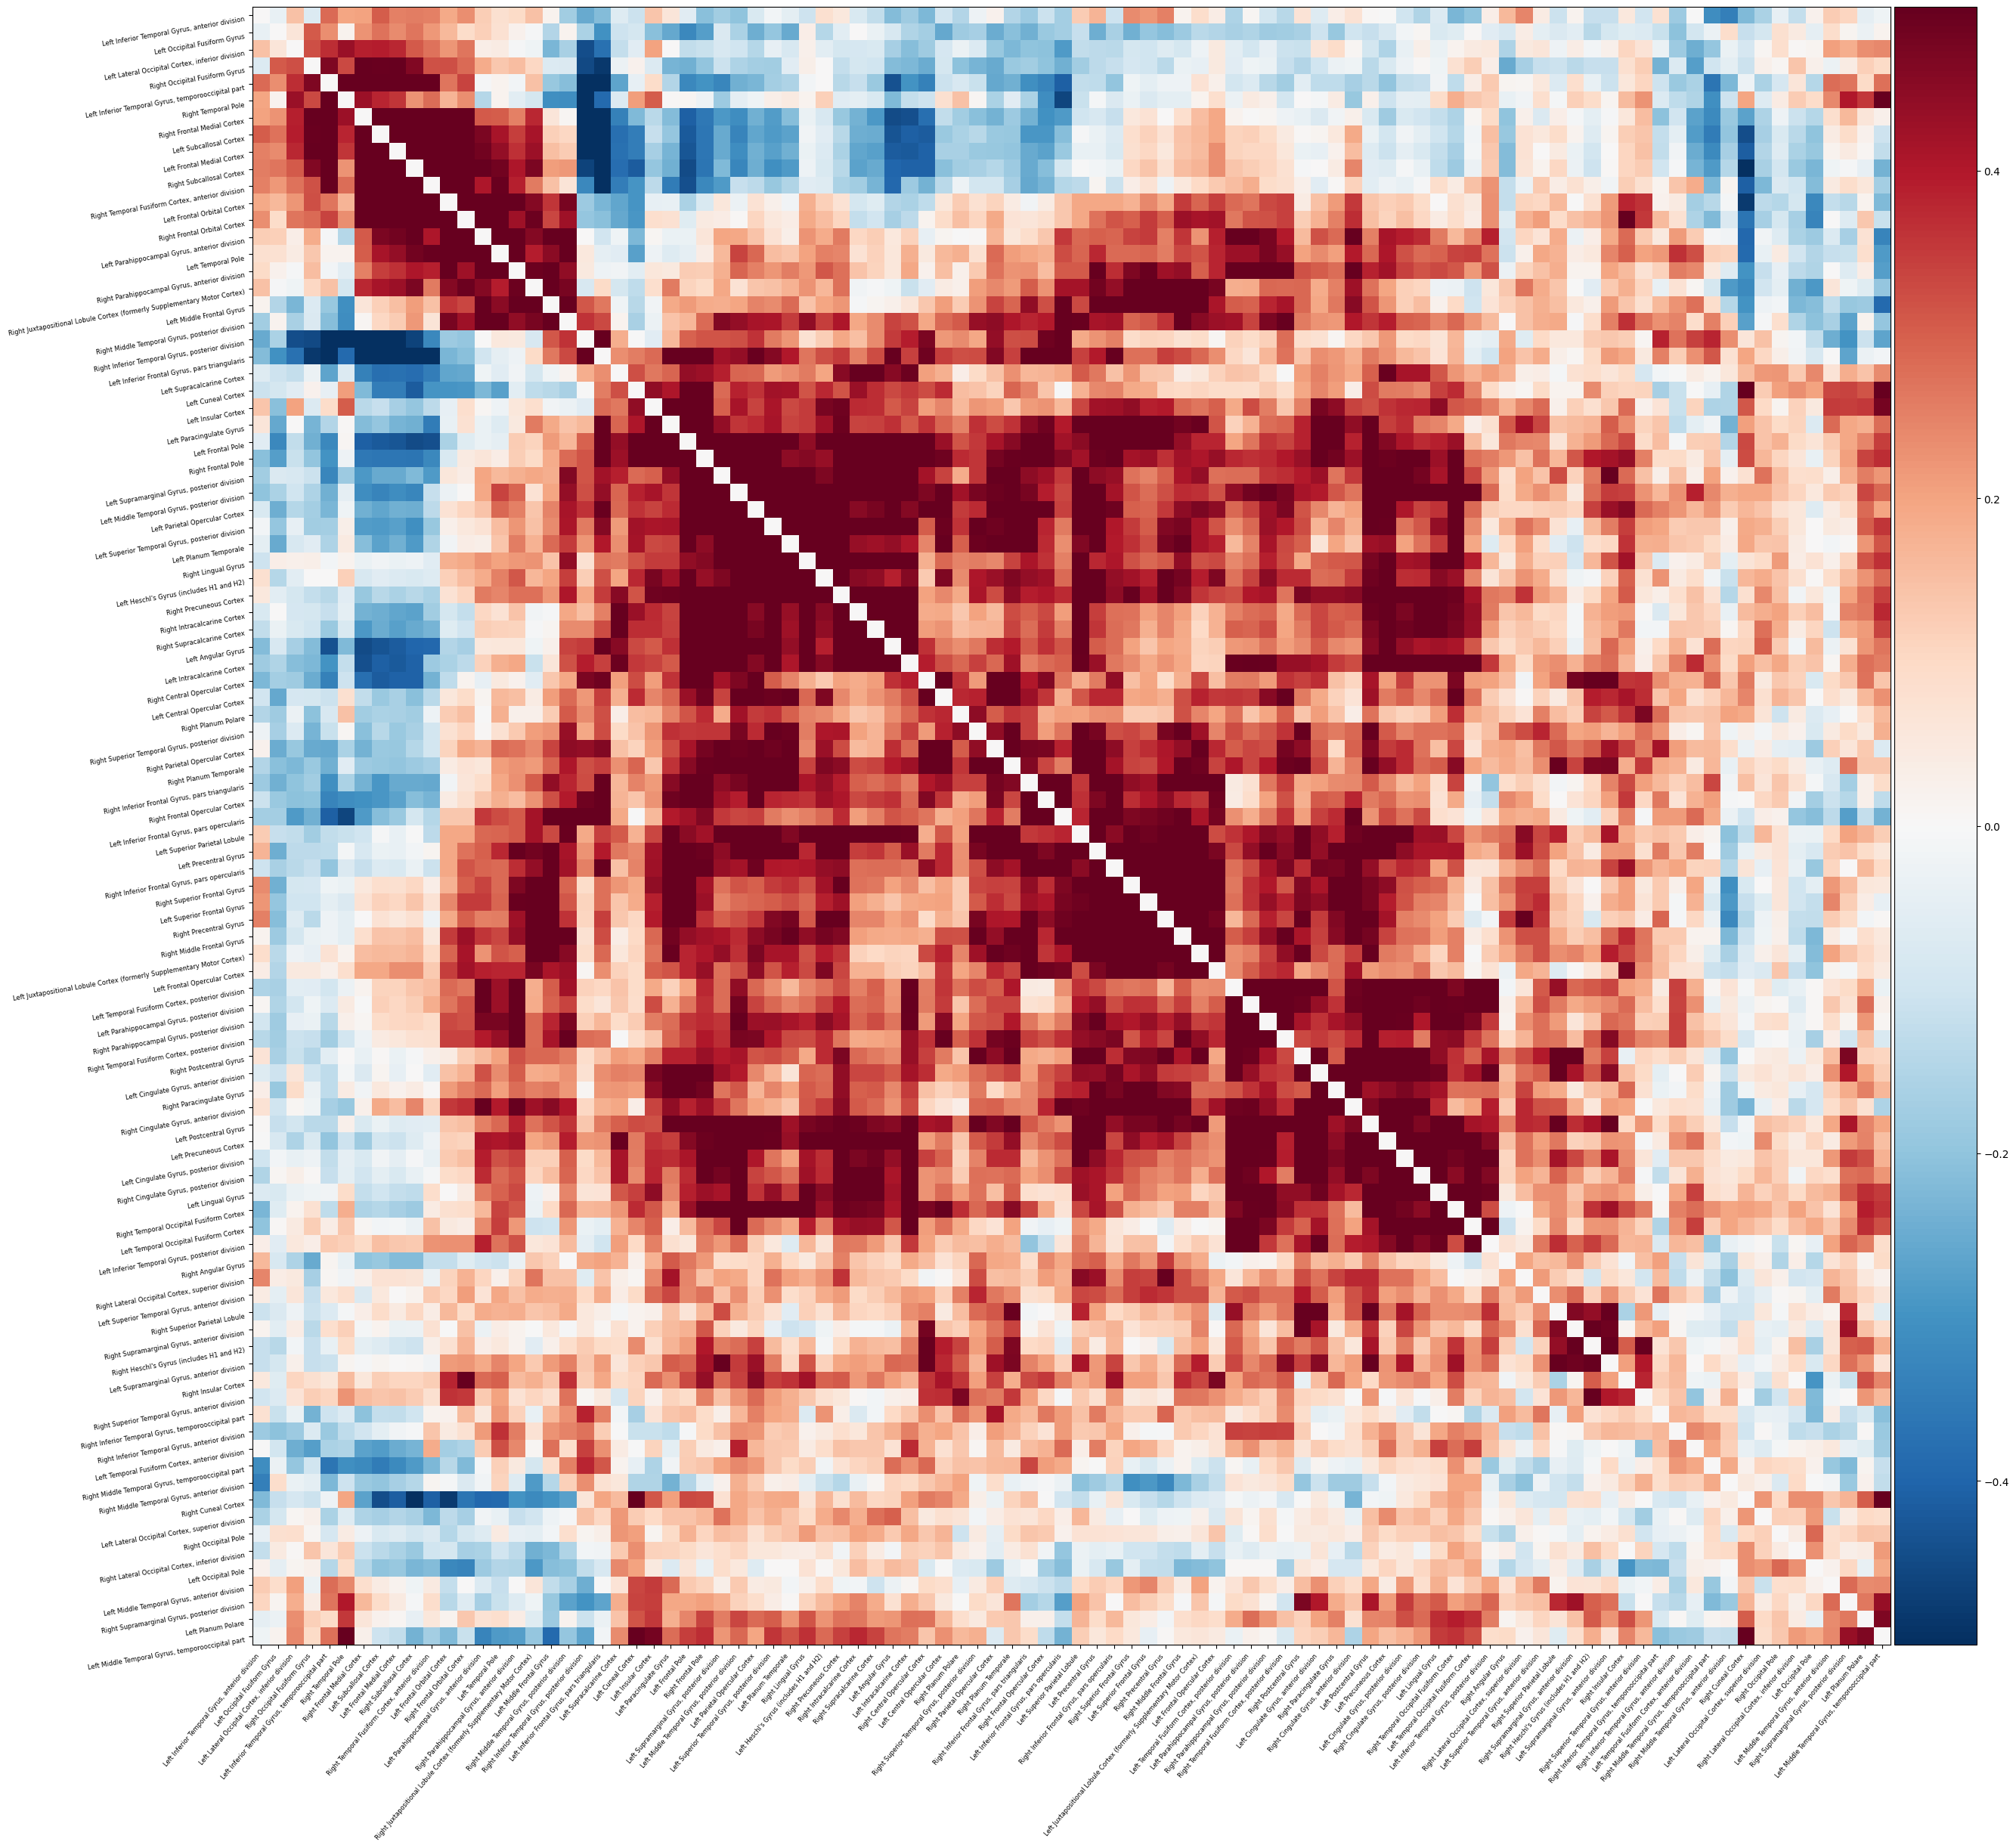

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets, image
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn import plotting

atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm', symmetric_split=True)

labels_masker = NiftiLabelsMasker(
    labels_img=atlas.maps, #atlas sin ajustar al cerebro
    standardize="zscore",      
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=recording.func.sampling_period,
    memory="nilearn_cache",
    memory_level=1,
    verbose=1,
    resampling_target='labels', #de aqui para abajo son cosas para que lla matriz siempre tenga el mismo tamaño
    keep_masked_labels=True)

# Extraemos las series temporales
region_time_series = labels_masker.fit_transform(recording.func.img)

# 4. Calculamos la matriz de conectividad (correlación de Pearson)
connectivity_measure = ConnectivityMeasure(
    kind='correlation', 
    standardize="zscore"
)
connectivity_matrices = connectivity_measure.fit_transform([region_time_series])
matrix = connectivity_matrices[0]

# --- PASO 5: VISUALIZACIÓN ADAPTADA ---

# Hacemos una copia y ponemos la diagonal a 0 para que no tape los contrastes reales
plot_matrix = matrix.copy()
np.fill_diagonal(plot_matrix, 0)

# Creamos el lienzo GIGANTE en Matplotlib para dar espacio a los nombres
fig, ax = plt.subplots(figsize=(26, 26))

# Pintamos la matriz (Quitamos fontsize de aquí para corregir el AttributeError)
plotting.plot_matrix(
    plot_matrix,
    labels=atlas.labels[1:], # Tus etiquetas originales completas sin el fondo
    cmap='RdBu_r',           # Paleta Rojo-Azul
    vmax=0.5,                # Saturamos el color a 0.5 para hiper-contraste
    vmin=-0.5,
    colorbar=True,
    reorder='average',       # Clustering jerárquico para agrupar las redes funcionales
    axes=ax                  
)

# --- CONTROL TOTAL DEL TEXTO CON MATPLOTLIB ---
# Modificamos el tamaño de letra (size=6) directamente sobre los ejes de Matplotlib
ax.tick_params(axis='both', labelsize=6)

# Rotamos las etiquetas del eje X para lectura vertical perfecta sin que se pisen
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Mapa conectividad

In [ ]:
import numpy as np
from nilearn import plotting

# --- REQUISITO: Traemos los IDs presentes del paso anterior ---
# (Esto viene de tu bloque de código anterior)
atlas_data = atlas_native.get_fdata()
present_ids = np.unique(atlas_data)
present_ids = present_ids[present_ids != 0].astype(int)


# 1. Calculamos las coordenadas usando el atlas ORIGINAL (en espacio MNI)
# Genera 96 coordenadas en total
coords_mni_completas = plotting.find_parcellation_cut_coords(atlas_filename)

# NUEVO: Filtramos las coordenadas para quedarnos solo con las 95 de la matriz.
# Restamos 1 porque present_ids va de 1 a 96, pero los índices de Python van de 0 a 95.
coords_filtradas = coords_mni_completas[present_ids - 1]


# 2. Dibujamos el conectoma 
# Ahora combinamos tu matriz real (95x95) con las coordenadas correspondientes (95x3)
plotting.plot_connectome(
    adjacency_matrix=matrix,         
    node_coords=coords_filtradas,       # <--- Usamos las coordenadas filtradas
    edge_threshold='95%',               # Prueba a bajarlo a '80%' si quieres ver más hilos
    title="Conectoma del Paciente (Proyectado en Espacio Estándar)"
)

plotting.show()